# Credit Card Fraud Detection — Dataset Audit & Exploratory Data Analysis

**CodSoft Data Science Internship — Task 5: Credit Card Fraud Detection**
(local folder `Task3_Credit_Card_Fraud_Detection`, my own project numbering)

**Phase 1 only.** This notebook audits the raw dataset and explores it. No model is trained,
nothing is scaled or normalised, no class balancing is applied, no row is dropped and nothing
is written back to the raw data file. The raw CSV is checksummed at the start and again at the
end to prove it was not touched.

---
## 1. Project Objective

The CodSoft task statement describes the problem as:

> Build a machine learning model to identify fraudulent credit card transactions. Preprocess and
> normalize the transaction data, handle class imbalance issues, and split the dataset into training
> and testing sets. Train a classification algorithm, such as logistic regression or random forests,
> to classify transactions as fraudulent or genuine. Evaluate the model's performance using metrics
> like precision, recall, and F1-score, and consider techniques like oversampling or undersampling
> for improving results.

The goal of **this phase** is narrower and deliberately so: understand the data before modelling it.
Specifically, establish (a) exactly what the file contains, (b) how severe the class imbalance is,
(c) which columns sit on which scale, and (d) what preprocessing the later phases will actually need.

A note on scope, so that nothing is claimed which the data does not support: the features `V1`–`V28`
are **anonymised principal components**, not raw business attributes. The dataset's own documentation
states that the original features could not be released for confidentiality reasons and that `V1`–`V28`
are the principal components obtained with PCA. Only `Time`, `Amount` and `Class` are supplied in their
original form. This notebook can therefore describe *how* the components differ between classes, but it
cannot name the underlying behaviour any component represents — and it does not try to.

---
## 2. Dataset Provenance

The dataset is the one the CodSoft source document links to, traced end to end:

| | |
|---|---|
| **CodSoft source document** | `DATA SCIENCE.pdf`, page 11 — "TASK 5 — CREDIT CARD FRAUD DETECTION — DATASET CLICK HERE" |
| **Link behind "CLICK HERE"** | `https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud` |
| **Kaggle dataset identifier** | `mlg-ulb/creditcardfraud` |
| **Owner** | Machine Learning Group — ULB (Université Libre de Bruxelles) |
| **Common name** | Credit Card Fraud Detection |
| **Downloaded archive** | `archive.zip`, 69,155,672 bytes, from Kaggle's public dataset download endpoint |
| **Archive member** | `creditcard.csv` — the archive's only file |
| **Extracted to** | `dataset/creditcard.csv` |
| **Licence** | Database Contents Licence (DbCL) 1.0, as stated on the Kaggle dataset page |

The hyperlink was read out of the PDF's annotation objects rather than typed from the visible text, so
the target is the one CodSoft actually embedded. No substitute, mirror, look-alike Kaggle dataset,
GitHub CSV or synthetic sample was used, and the extracted CSV was not edited in any way.

**What the dataset is.** It contains transactions made by European cardholders using credit cards in
September 2013, covering two days of activity. It is the dataset described in Dal Pozzolo et al.,
*Calibrating Probability with Undersampling for Unbalanced Classification* (IEEE Symposium Series on
Computational Intelligence, 2015), collected during a research collaboration between Worldline and the
ULB Machine Learning Group.

Every provenance figure quoted above is re-verified programmatically in sections 3.1–3.2 below.

---
## 3. Imports and Configuration

In [1]:
import hashlib
import platform
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 42  # fixed, for any sampling used for display purposes only

# Two-colour categorical assignment held constant across every figure in this notebook:
# colour follows the class, never the rank or the ordering of a plot. The pair was checked
# for colour-vision-deficiency separation before use (worst case protanopia dE 30.1,
# normal vision dE 37.8 - both well above the dE 8 target).
C_LEGIT = "#3b5bdb"
C_FRAUD = "#e8590c"
CLASS_COLORS = {0: C_LEGIT, 1: C_FRAUD}
CLASS_LABELS = {0: "Legitimate (Class 0)", 1: "Fraudulent (Class 1)"}

print("python    ", sys.version.split()[0])
print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn   ", sns.__version__)
print("platform  ", platform.system(), platform.release())

python     3.13.0
pandas     3.0.6
numpy      2.5.3
matplotlib 3.11.2
seaborn    0.13.2
platform   Windows 11


### Repository-relative paths

Paths are resolved from the notebook's own location, so the notebook runs from anywhere in the
repository and contains no absolute Windows paths.

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").is_dir() else NOTEBOOK_DIR.parent

DATASET_PATH = PROJECT_DIR / "dataset" / "creditcard.csv"
VIZ_DIR = PROJECT_DIR / "visualizations"
VIZ_DIR.mkdir(exist_ok=True)

print("project directory:", PROJECT_DIR.name)
print("dataset file     :", DATASET_PATH.relative_to(PROJECT_DIR).as_posix())
print("dataset exists   :", DATASET_PATH.is_file())
print("visualizations   :", VIZ_DIR.relative_to(PROJECT_DIR).as_posix())

project directory: Task3_Credit_Card_Fraud_Detection
dataset file     : dataset/creditcard.csv
dataset exists   : True
visualizations   : visualizations


### 3.1 Raw-file fingerprint, taken *before* anything is read

The SHA-256 digest is computed now and re-computed in section 17. If the two differ, the audit
modified the raw data and this phase has failed.

In [3]:
def sha256_of(path: Path, chunk: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            digest.update(block)
    return digest.hexdigest()

FILE_SIZE_BYTES = DATASET_PATH.stat().st_size
SHA256_INITIAL = sha256_of(DATASET_PATH)

print("file        :", DATASET_PATH.name)
print("size (bytes):", f"{FILE_SIZE_BYTES:,}")
print("size (MiB)  :", f"{FILE_SIZE_BYTES / 1024**2:,.2f}")
print("SHA-256     :", SHA256_INITIAL)

file        : creditcard.csv
size (bytes): 150,828,752
size (MiB)  : 143.84
SHA-256     : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89


### 3.2 Format, encoding and header, read from the bytes on disk

Before handing the file to pandas, the first two lines are read as raw bytes. That confirms the
delimiter, the quoting style, the line terminator and the encoding — none of which should be assumed
from the `.csv` extension alone.

In [4]:
with open(DATASET_PATH, "rb") as fh:
    raw_head = fh.read(4096)

header_bytes, first_record_bytes = raw_head.split(b"\n")[:2]

print("line terminator  :", "CRLF" if b"\r\n" in raw_head else "LF")
print("byte-order mark  :", raw_head.startswith(b"\xef\xbb\xbf"))
print("pure ASCII       :", all(byte < 128 for byte in raw_head))
print("delimiter        :", "comma" if header_bytes.count(b",") > 20 else "not comma")
print("header is quoted :", header_bytes.startswith(b'\x22'))
print("values are quoted:", first_record_bytes.startswith(b'\x22'))
print()
print("header line :", header_bytes.decode("utf-8")[:150], "...")
print("first record:", first_record_bytes.decode("utf-8")[:150], "...")

line terminator  : LF
byte-order mark  : False
pure ASCII       : True
delimiter        : comma
header is quoted : True
values are quoted: False

header line : "Time","V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V ...
first record: 0,-1.3598071336738,-0.0727811733098497,2.53634673796914,1.37815522427443,-0.338320769942518,0.462387777762292,0.239598554061257,0.0986979012610507,0.3 ...


The header is quoted but the data values are not, and the file is comma-delimited plain ASCII with
LF line endings — exactly what `pd.read_csv` handles with no arguments.

---
## 4. Load Raw Dataset

The file is read exactly as it sits on disk: no `dtype` overrides, no `na_values`, no `index_col`,
no renaming. Everything reported below therefore describes the raw file. `df` is treated as read-only
for the rest of the notebook; wherever a derived frame is needed it is an explicit `.copy()`.

In [5]:
df = pd.read_csv(DATASET_PATH)

print("loaded:", DATASET_PATH.name)
df.head()

loaded: creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [6]:
df.tail(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284804,"172,788.0000",1.9196,-0.3013,-3.2496,-0.5578,2.6305,3.0313,-0.2968,0.7084,0.4325,-0.4848,0.4116,0.0631,-0.1837,-0.5106,1.3293,0.1407,0.3135,0.3957,-0.5773,0.0014,0.2320,0.5782,-0.0375,0.6401,0.2657,-0.0874,0.0045,-0.0266,67.8800,0
284805,"172,788.0000",-0.2404,0.5305,0.7025,0.6898,-0.3780,0.6237,-0.6862,0.6791,0.3921,-0.3991,-1.9338,-0.9629,-1.0421,0.4496,1.9626,-0.6086,0.5099,1.1140,2.8978,0.1274,0.2652,0.8000,-0.1633,0.1232,-0.5692,0.5467,0.1088,0.1045,10.0000,0
284806,"172,792.0000",-0.5334,-0.1897,0.7033,-0.5063,-0.0125,-0.6496,1.5770,-0.4147,0.4862,-0.9154,-1.0405,-0.0315,-0.1881,-0.0843,0.0413,-0.3026,-0.6604,0.1674,-0.2561,0.3829,0.2611,0.6431,0.3768,0.0088,-0.4736,-0.8183,-0.0024,0.0136,217.0000,0


---
## 5. Dataset Shape

In [7]:
n_rows, n_cols = df.shape

print(f"rows    : {n_rows:,}")
print(f"columns : {n_cols}")
print(f"cells   : {n_rows * n_cols:,}")
print()
print(f"in-memory size : {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MiB")
print(f"on-disk size   : {FILE_SIZE_BYTES / 1024**2:,.1f} MiB")

rows    : 284,807
columns : 31
cells   : 8,829,017

in-memory size : 67.4 MiB
on-disk size   : 143.8 MiB


The on-disk file is roughly twice the in-memory size because the CSV stores every principal component
as a long decimal string (15–17 significant digits), whereas pandas holds each as an 8-byte float64.

---
## 6. Column Information

The expected layout for this dataset is `Time`, `V1`–`V28`, `Amount`, `Class`. That expectation is
**checked against the file** rather than assumed — the comparison below would fail loudly if the
download were a differently-shaped look-alike.

In [8]:
actual_columns = list(df.columns)
expected_columns = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]

print("column count:", len(actual_columns))
print("columns     :", actual_columns)
print()
print("matches the expected Time / V1-V28 / Amount / Class layout:", actual_columns == expected_columns)
print("duplicate column names                                    :",
      len(actual_columns) != len(set(actual_columns)))
print("leading/trailing whitespace in any name                   :",
      any(name != name.strip() for name in actual_columns))

column count: 31
columns     : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

matches the expected Time / V1-V28 / Amount / Class layout: True
duplicate column names                                    : False
leading/trailing whitespace in any name                   : False


In [9]:
V_COLS = [f"V{i}" for i in range(1, 29)]
TARGET = "Class"
FEATURE_COLS = [c for c in actual_columns if c != TARGET]

print(f"target        : {TARGET}")
print(f"features      : {len(FEATURE_COLS)}  ->  Time, V1..V28, Amount")
print(f"PCA components: {len(V_COLS)}  ->  {V_COLS[0]} .. {V_COLS[-1]}")

target        : Class
features      : 30  ->  Time, V1..V28, Amount
PCA components: 28  ->  V1 .. V28


---
## 7. Data Types

A compact per-column table: dtype, missing count, cardinality and the role each column plays. Every
value in it is generated from the frame; nothing is typed by hand.

In [10]:
def column_role(name: str) -> str:
    if name == TARGET:
        return "target (binary)"
    if name == "Time":
        return "feature - seconds since first transaction"
    if name == "Amount":
        return "feature - transaction amount"
    return "feature - anonymised PCA component"

column_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().sum() / n_rows * 100).round(4),
    "unique": df.nunique(),
    "numeric": [pd.api.types.is_numeric_dtype(df[c]) for c in df.columns],
    "role": [column_role(c) for c in df.columns],
})
column_audit.index.name = "column"
column_audit

,dtype,missing,missing_%,unique,numeric,role
column,,,,,,
Time,float64,0,0.0000,124592,True,feature - seconds since first transaction
V1,float64,0,0.0000,275663,True,feature - anonymised PCA component
V2,float64,0,0.0000,275663,True,feature - anonymised PCA component
V3,float64,0,0.0000,275663,True,feature - anonymised PCA component
V4,float64,0,0.0000,275663,True,feature - anonymised PCA component
V5,float64,0,0.0000,275663,True,feature - anonymised PCA component
V6,float64,0,0.0000,275663,True,feature - anonymised PCA component
V7,float64,0,0.0000,275663,True,feature - anonymised PCA component
V8,float64,0,0.0000,275663,True,feature - anonymised PCA component


In [11]:
print("dtype counts:")
print(df.dtypes.value_counts().to_string())
print()
print("all columns numeric     :", all(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns))
print("object / string columns :", list(df.select_dtypes(include="object").columns) or "none")
print("target dtype            :", df[TARGET].dtype)

dtype counts:
float64    30
int64       1

all columns numeric     : True
object / string columns : none
target dtype            : int64


Every column is numeric, so Phase 2 has no categorical-encoding work to do — a convenient property
that follows directly from the PCA transformation applied to the original data.

---
## 8. Missing-Value Audit

In [12]:
missing_per_column = df.isna().sum()
total_missing = int(missing_per_column.sum())
rows_with_missing = int(df.isna().any(axis=1).sum())

print(f"total missing cells        : {total_missing:,}  of {n_rows * n_cols:,}")
print(f"columns containing missing : {int((missing_per_column > 0).sum())}  of {n_cols}")
print(f"rows containing missing    : {rows_with_missing:,}  of {n_rows:,}")
print()
if total_missing == 0:
    print("No missing values were found in the raw dataset.")
else:
    print(missing_per_column[missing_per_column > 0].to_string())

total missing cells        : 0  of 8,829,017
columns containing missing : 0  of 31
rows containing missing    : 0  of 284,807

No missing values were found in the raw dataset.


Pandas' `NaN` check only catches values the parser read as null. Placeholder values — empty strings,
sentinel numbers such as `-999`, or infinities — would pass that check silently, so they are tested
for separately.

In [13]:
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()

print("infinite values         :", int(inf_counts.sum()))
print("empty-string cells      :", int((df.astype(str) == "").sum().sum()))
print("rows fully duplicated as blank:", int((df.isna().all(axis=1)).sum()))
print()
print("classic sentinel scan (-999 / -1 in Amount / negative Amount):")
print("  Amount == -999 :", int((df["Amount"] == -999).sum()))
print("  Amount  <  0   :", int((df["Amount"] < 0).sum()))
print("  Time    <  0   :", int((df["Time"] < 0).sum()))

infinite values         : 0


empty-string cells      : 0
rows fully duplicated as blank: 0

classic sentinel scan (-999 / -1 in Amount / negative Amount):
  Amount == -999 : 0
  Amount  <  0   : 0
  Time    <  0   : 0


**Finding.** No missing values were found in the raw dataset, and no disguised placeholder was found
either: no infinities, no empty strings, no negative `Amount` or `Time`. Phase 2 therefore needs no
imputation strategy at all.

---
## 9. Duplicate Audit

Duplicates are **counted and investigated here, not removed.** In a fraud dataset a repeated-looking
row is not automatically an error: the features are anonymised principal components rounded to finite
precision, so two genuinely distinct small transactions occurring close together can legitimately
collapse onto identical values. The decision about what to do with them belongs to Phase 2, informed
by what this section finds.

In [14]:
dup_full = df.duplicated()                                    # second and later copies
dup_full_all = df.duplicated(keep=False)                      # every row in a duplicated group
dup_features_only = df.duplicated(subset=FEATURE_COLS)        # ignoring the target

n_dup = int(dup_full.sum())
n_dup_all = int(dup_full_all.sum())
n_dup_features = int(dup_features_only.sum())

print(f"exact duplicate rows (extra copies)      : {n_dup:,}  ({n_dup / n_rows * 100:.4f}% of the dataset)")
print(f"rows involved in a duplicate group       : {n_dup_all:,}  ({n_dup_all / n_rows * 100:.4f}%)")
print(f"distinct duplicated groups               : {n_dup_all - n_dup:,}")
print(f"duplicates on features only (Class ignored): {n_dup_features:,}")
print()
print("conflicting labels (identical features, different Class):", n_dup_features - n_dup)

exact duplicate rows (extra copies)      : 1,081  (0.3796% of the dataset)
rows involved in a duplicate group       : 1,854  (0.6510%)
distinct duplicated groups               : 773
duplicates on features only (Class ignored): 1,081

conflicting labels (identical features, different Class): 0


`n_dup_features == n_dup` means **no row pair shares its 30 features while disagreeing on `Class`.**
That matters: had duplicated features carried contradictory labels, the dataset would contain
irreducible label noise and no classifier could separate those rows. It does not.

In [15]:
dup_rows = df[dup_full_all]
dup_by_class = dup_rows[TARGET].value_counts().sort_index()

dup_summary = pd.DataFrame({
    "rows_in_duplicate_groups": dup_by_class,
    "class_total": df[TARGET].value_counts().sort_index(),
})
dup_summary["% of that class"] = (dup_summary["rows_in_duplicate_groups"] /
                                  dup_summary["class_total"] * 100).round(3)
dup_summary.index = [CLASS_LABELS[i] for i in dup_summary.index]
dup_summary

,rows_in_duplicate_groups,class_total,% of that class
Legitimate (Class 0),1822,284315,0.6410
Fraudulent (Class 1),32,492,6.5040


In [16]:
group_sizes = dup_rows.groupby(FEATURE_COLS + [TARGET], sort=False).size()

print("duplicate group size distribution (rows per repeated combination):")
print(group_sizes.value_counts().sort_index().rename("groups").to_string())
print()
print("largest duplicate group:", int(group_sizes.max()), "identical rows")
print()
print("amount profile of duplicated rows vs the whole dataset:")
print(pd.DataFrame({
    "duplicated rows": dup_rows["Amount"].describe(),
    "all rows": df["Amount"].describe(),
}).round(2).to_string())

duplicate group size distribution (rows per repeated combination):
2     611
3      66
4      81
5      10
6       1
9       2
18      2

largest duplicate group: 18 identical rows

amount profile of duplicated rows vs the whole dataset:
       duplicated rows     all rows
count       1,854.0000 284,807.0000
mean           60.0900      88.3500
std           166.0700     250.1200
min             0.0000       0.0000
25%             6.0000       5.6000
50%            15.9800      22.0000
75%            36.0000      77.1600
max         1,848.0600  25,691.1600


**Finding and decision.** Duplicates exist but are a small fraction of the data, they are
overwhelmingly small-value transactions, and none of them carries a conflicting label. They are
**retained unchanged in Phase 1.** Phase 2 will decide whether to drop the extra copies, and the
argument to do so is not "duplicates are dirty" but "identical rows appearing in both the training and
test split would leak information across the split and inflate the test score." That is a splitting
concern, which is exactly where it will be handled.

---
## 10. Target / Class Distribution

In [17]:
class_counts = df[TARGET].value_counts().sort_index()
class_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100

n_legit = int(class_counts.loc[0])
n_fraud = int(class_counts.loc[1])

print("unique target values :", sorted(df[TARGET].unique()))
print("target is binary     :", set(df[TARGET].unique()) == {0, 1})
print("both classes present :", n_legit > 0 and n_fraud > 0)
print()
target_table = pd.DataFrame({
    "count": class_counts,
    "percent": class_pct.round(6),
})
target_table.index = [CLASS_LABELS[i] for i in target_table.index]
target_table

unique target values : [np.int64(0), np.int64(1)]
target is binary     : True
both classes present : True



,count,percent
Legitimate (Class 0),284315,99.8273
Fraudulent (Class 1),492,0.1727


In [18]:
imbalance_ratio = n_legit / n_fraud
minority_share = n_fraud / n_rows * 100

print(f"legitimate transactions : {n_legit:,}   ({n_legit / n_rows * 100:.6f}%)")
print(f"fraudulent transactions : {n_fraud:,}      ({minority_share:.6f}%)")
print()
print(f"imbalance ratio         : {imbalance_ratio:.4f} legitimate per 1 fraudulent")
print(f"                          i.e. roughly {imbalance_ratio:,.0f} : 1")
print(f"minority class size     : {n_fraud:,} rows")
print(f"majority class size     : {n_legit:,} rows")
print(f"fraud rate              : 1 in {n_rows / n_fraud:,.0f} transactions")

legitimate transactions : 284,315   (99.827251%)
fraudulent transactions : 492      (0.172749%)

imbalance ratio         : 577.8760 legitimate per 1 fraudulent
                          i.e. roughly 578 : 1
minority class size     : 492 rows
majority class size     : 284,315 rows
fraud rate              : 1 in 579 transactions


---
## 11. Class Imbalance Analysis

This is the defining characteristic of the dataset and the part of the CodSoft brief that says
"handle class imbalance issues". The numbers above are stated precisely rather than rounded, because
rounding is what hides the problem.

### Why accuracy is the wrong metric here

A model that predicts "legitimate" for every single transaction, learns nothing, and is useless in
production would still score the accuracy computed below.

In [19]:
majority_baseline_accuracy = n_legit / n_rows * 100

print(f"accuracy of a model that always predicts 'legitimate' : {majority_baseline_accuracy:.4f}%")
print(f"                                          its recall  : 0.0000%  (it catches no fraud)")
print(f"                                       its precision  : undefined (it never predicts fraud)")
print()
print(f"frauds such a model would miss                        : {n_fraud:,} of {n_fraud:,}")

accuracy of a model that always predicts 'legitimate' : 99.8273%
                                          its recall  : 0.0000%  (it catches no fraud)
                                       its precision  : undefined (it never predicts fraud)

frauds such a model would miss                        : 492 of 492


So a headline accuracy of about 99.83% is the *floor*, not an achievement. Any accuracy figure quoted
for this problem has to be compared against that baseline, and a model beating it by a fraction of a
percent may still be catching no fraud at all.

The metrics that do carry information here are the ones the CodSoft brief names:

| Metric | What it answers | Why it matters for fraud |
|---|---|---|
| **Recall** (sensitivity) | of all actual frauds, how many were caught? | a missed fraud is a direct financial loss |
| **Precision** | of all flagged transactions, how many were really fraud? | false alarms block genuine customers and cost review time |
| **F1-score** | harmonic mean of the two | single number when both errors matter |
| **PR-AUC / average precision** | precision-recall trade-off across all thresholds | threshold-free, and unlike ROC-AUC it is not flattered by the huge negative class |

### What will *not* be done in this phase

No oversampling, no undersampling, no SMOTE, no class weights. Those are modelling decisions and they
belong to later phases, for a specific reason: resampling must be applied **inside** the training fold
only. Resampling the full dataset here and splitting afterwards would place synthetic or duplicated
copies of minority rows on both sides of the split and produce a test score that cannot be trusted.

Strategies to be investigated in later phases, once a train/test split exists:

- `class_weight="balanced"` on logistic regression and random forest — cheapest option, no data invented
- `RandomUnderSampler` on the majority class — fast, discards a great deal of legitimate data
- `RandomOverSampler` on the minority class — duplicates the 492 fraud rows, risks overfitting them
- `SMOTE` — synthesises new minority points; note the features are PCA components, so interpolating
  between them is at least geometrically coherent, though still synthetic
- threshold tuning on predicted probabilities — often the most effective single lever, and it needs
  no resampling at all

### Visualisation 1 — class distribution

Two panels, because the imbalance cannot be shown honestly on a single scale: a linear bar chart
makes the fraud bar invisible, and a log chart alone understates the gap to the eye. Both are shown,
with the counts labelled directly so the reader never has to measure a bar against an axis.

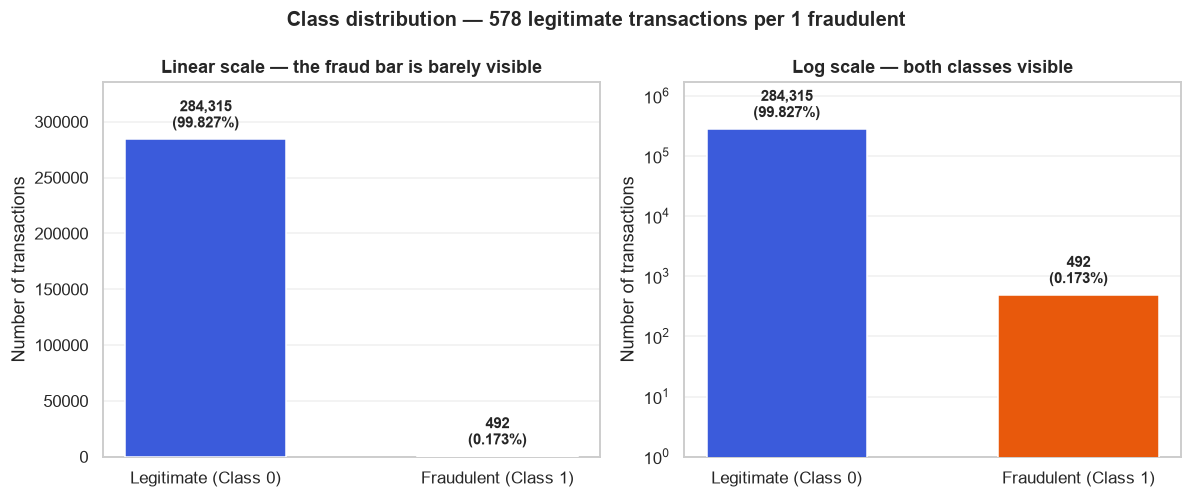

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

labels = [CLASS_LABELS[0], CLASS_LABELS[1]]
values = [n_legit, n_fraud]
colors = [C_LEGIT, C_FRAUD]

for ax, log_scale in zip(axes, [False, True]):
    bars = ax.bar(labels, values, color=colors, width=0.55, zorder=3)
    if log_scale:
        ax.set_yscale("log")
        ax.set_title("Log scale — both classes visible")
        ax.set_ylim(1, n_legit * 6)
    else:
        ax.set_title("Linear scale — the fraud bar is barely visible")
        ax.set_ylim(0, n_legit * 1.18)
    for bar, value in zip(bars, values):
        ax.annotate(f"{value:,}\n({value / n_rows * 100:.3f}%)",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    ax.set_ylabel("Number of transactions")
    ax.set_xlabel("")
    ax.grid(axis="x", visible=False)

fig.suptitle(f"Class distribution — {imbalance_ratio:,.0f} legitimate transactions per 1 fraudulent",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "01_class_distribution.png")
plt.show()

---
## 12. Numerical Feature Statistics

Full descriptive statistics for all 31 columns: count, mean, standard deviation, minimum, the three
quartiles and maximum.

In [21]:
describe_all = df.describe().T
describe_all.index.name = "column"
describe_all.round(4)

,count,mean,std,min,25%,50%,75%,max
column,,,,,,,,
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072


Reading that table, three groups behave very differently:

- **`Time`** — a bounded counter running from 0 to about 172,800, uniform-ish rather than bell-shaped.
- **`Amount`** — strictly non-negative, median far below the mean, extreme right tail.
- **`V1`–`V28`** — all centred on essentially zero, with standard deviations that decrease steadily
  from `V1` to `V28`. That descending variance is the signature of principal components ordered by
  explained variance, and it confirms the documentation's claim about how they were produced.

In [22]:
component_stats = df[V_COLS].agg(["mean", "std", "min", "max"]).T
component_stats.index.name = "component"

print("mean of all 28 component means (should be ~0):", f"{component_stats['mean'].mean():.2e}")
print("largest absolute component mean              :", f"{component_stats['mean'].abs().max():.2e}")
print()
print("component standard deviations are monotonically decreasing V1 -> V28:",
      bool((component_stats["std"].diff().dropna() < 0).all()))
print(f"std ranges from {component_stats['std'].max():.4f} (V1) down to "
      f"{component_stats['std'].min():.4f} (V28)")
component_stats.round(4)

mean of all 28 component means (should be ~0): 7.67e-16
largest absolute component mean              : 4.87e-15

component standard deviations are monotonically decreasing V1 -> V28: True
std ranges from 1.9587 (V1) down to 0.3301 (V28)


,mean,std,min,max
component,,,,
V1,0.0000,1.9587,-56.4075,2.4549
V2,0.0000,1.6513,-72.7157,22.0577
V3,-0.0000,1.5163,-48.3256,9.3826
V4,0.0000,1.4159,-5.6832,16.8753
V5,0.0000,1.3802,-113.7433,34.8017
V6,0.0000,1.3323,-26.1605,73.3016
V7,-0.0000,1.2371,-43.5572,120.5895
V8,0.0000,1.1944,-73.2167,20.0072
V9,-0.0000,1.0986,-13.4341,15.5950


---
## 13. Feature Scale Audit

What Phase 2's normalisation step actually has to fix. The comparison is by feature *group*, because
28 of the 31 columns already share a common scale.

In [23]:
scale_groups = {
    "Time (seconds)": df[["Time"]],
    "Amount (currency)": df[["Amount"]],
    "V1-V28 (PCA components)": df[V_COLS],
}

scale_rows = []
for name, block in scale_groups.items():
    values = block.to_numpy()
    scale_rows.append({
        "feature group": name,
        "columns": block.shape[1],
        "min": values.min(),
        "max": values.max(),
        "range": values.max() - values.min(),
        "mean": values.mean(),
        "std": values.std(),
    })

scale_table = pd.DataFrame(scale_rows).set_index("feature group")
scale_table.round(4)

,columns,min,max,range,mean,std
feature group,,,,,,
Time (seconds),1,0.0000,"172,792.0000","172,792.0000","94,813.8596","47,488.0626"
Amount (currency),1,0.0000,"25,691.1600","25,691.1600",88.3496,250.1197
V1-V28 (PCA components),28,-113.7433,120.5895,234.3328,0.0000,1.0476


In [24]:
time_range = df["Time"].max() - df["Time"].min()
amount_range = df["Amount"].max() - df["Amount"].min()
component_range = df[V_COLS].to_numpy().max() - df[V_COLS].to_numpy().min()

print(f"Time  range : {time_range:,.2f}")
print(f"Amount range: {amount_range:,.2f}")
print(f"V1-V28 range: {component_range:,.2f}")
print()
print(f"Time spans  {time_range / component_range:,.0f}x the full component range")
print(f"Amount spans {amount_range / component_range:,.0f}x the full component range")

Time  range : 172,792.00
Amount range: 25,691.16
V1-V28 range: 234.33

Time spans  737x the full component range
Amount spans 110x the full component range


**Implication for Phase 2.** `Time` and `Amount` are on scales hundreds of times wider than the
principal components. For any distance- or gradient-based model — logistic regression above all —
those two columns would dominate the objective purely through magnitude. They need scaling. The
components themselves are already approximately standardised as a by-product of PCA, but scaling them
too is harmless and keeps the pipeline uniform.

**Not done here.** No scaler is fitted in this notebook. When one is fitted in Phase 2 it must be fitted
on the training split alone and then applied to the test split, never fitted on the full dataset —
otherwise the test set's distribution leaks into the transformation.

---
## 14. Transaction Amount Analysis

In [25]:
amount = df["Amount"]

amount_stats = pd.Series({
    "count": amount.count(),
    "mean": amount.mean(),
    "std": amount.std(),
    "min": amount.min(),
    "1%": amount.quantile(0.01),
    "25%": amount.quantile(0.25),
    "50% (median)": amount.median(),
    "75%": amount.quantile(0.75),
    "95%": amount.quantile(0.95),
    "99%": amount.quantile(0.99),
    "max": amount.max(),
    "skewness": amount.skew(),
    "kurtosis": amount.kurt(),
}, name="Amount")

print(amount_stats.round(4).to_string())
print()
n_zero_amount = int((amount == 0).sum())
print(f"zero-amount transactions : {n_zero_amount:,}  ({n_zero_amount / n_rows * 100:.4f}%)")
print("  of which fraudulent    :", int(((amount == 0) & (df[TARGET] == 1)).sum()))
print("  of which legitimate    :", int(((amount == 0) & (df[TARGET] == 0)).sum()))
print(f"negative amounts         : {int((amount < 0).sum())}")

count          284,807.0000
mean                88.3496
std                250.1201
min                  0.0000
1%                   0.1200
25%                  5.6000
50% (median)        22.0000
75%                 77.1650
95%                365.0000
99%              1,017.9700
max             25,691.1600
skewness            16.9777
kurtosis           845.0926

zero-amount transactions : 1,825  (0.6408%)
  of which fraudulent    : 27
  of which legitimate    : 1798
negative amounts         : 0


The mean sits well above the median and skewness is around 17, so the distribution is heavily
right-skewed: a large mass of small transactions with a thin tail reaching past 25,000. There are also
a number of exactly-zero amounts, present in both classes — plausibly card authorisation checks rather
than corrupt records, so they are kept and simply noted.

### Visualisation 2 — amount distribution

The raw histogram is shown alongside a `log1p` view. **The log transform is applied for visualisation
only**, inside the plotting call, on a copy of the values; the column in `df` and the file on disk are
untouched. Without it the entire distribution collapses into the leftmost bin.

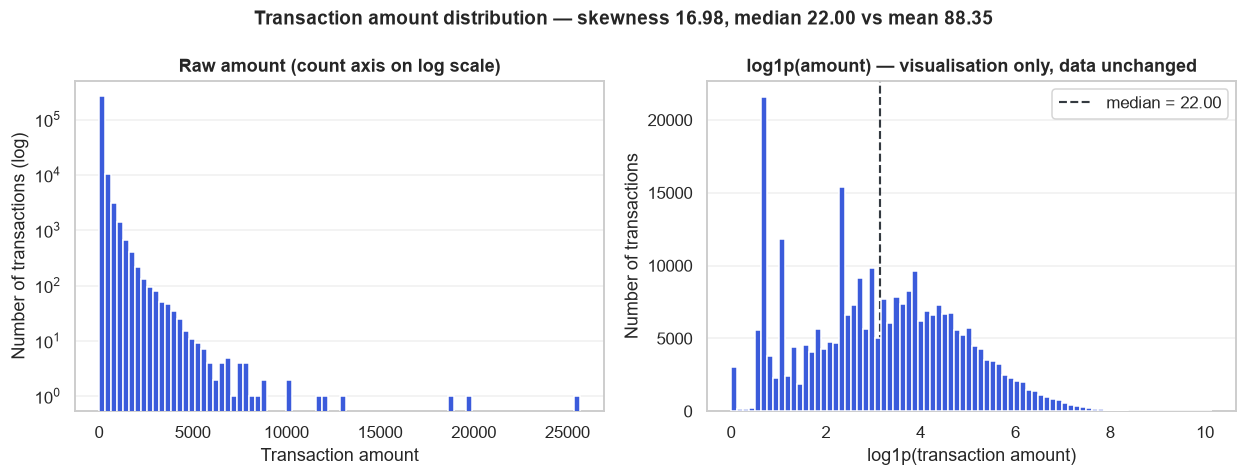

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

axes[0].hist(amount, bins=80, color=C_LEGIT, zorder=3)
axes[0].set_yscale("log")
axes[0].set_title("Raw amount (count axis on log scale)")
axes[0].set_xlabel("Transaction amount")
axes[0].set_ylabel("Number of transactions (log)")

axes[1].hist(np.log1p(amount), bins=80, color=C_LEGIT, zorder=3)
axes[1].set_title("log1p(amount) — visualisation only, data unchanged")
axes[1].set_xlabel("log1p(transaction amount)")
axes[1].set_ylabel("Number of transactions")
axes[1].axvline(np.log1p(amount.median()), color="#343a40", linestyle="--", linewidth=1.4,
                label=f"median = {amount.median():,.2f}")
axes[1].legend(frameon=True)

for ax in axes:
    ax.grid(axis="x", visible=False)

fig.suptitle(f"Transaction amount distribution — skewness {amount.skew():.2f}, "
             f"median {amount.median():,.2f} vs mean {amount.mean():,.2f}",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "02_amount_distribution.png")
plt.show()

### Amount by class

In [27]:
amount_by_class = df.groupby(TARGET)["Amount"].agg(
    count="count", mean="mean", median="median", std="std", min="min",
    q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75),
    q99=lambda s: s.quantile(0.99), max="max",
)
amount_by_class.index = [CLASS_LABELS[i] for i in amount_by_class.index]
amount_by_class.round(4)

,count,mean,median,std,min,q25,q75,q99,max
Legitimate (Class 0),284315,88.2910,22.0000,250.1051,0.0000,5.6500,77.0500,"1,016.9664","25,691.1600"
Fraudulent (Class 1),492,122.2113,9.2500,256.6833,0.0000,1.0000,105.8900,"1,357.4279","2,125.8700"


In [28]:
legit_amount = df.loc[df[TARGET] == 0, "Amount"]
fraud_amount = df.loc[df[TARGET] == 1, "Amount"]

print(f"mean   — legitimate {legit_amount.mean():8,.2f}   fraudulent {fraud_amount.mean():8,.2f}")
print(f"median — legitimate {legit_amount.median():8,.2f}   fraudulent {fraud_amount.median():8,.2f}")
print(f"max    — legitimate {legit_amount.max():8,.2f}   fraudulent {fraud_amount.max():8,.2f}")
print()
print("Fraudulent transactions have the HIGHER mean but the LOWER median, and their maximum is an")
print("order of magnitude smaller than the legitimate maximum.")

mean   — legitimate    88.29   fraudulent   122.21
median — legitimate    22.00   fraudulent     9.25
max    — legitimate 25,691.16   fraudulent 2,125.87

Fraudulent transactions have the HIGHER mean but the LOWER median, and their maximum is an
order of magnitude smaller than the legitimate maximum.


That combination is worth stating carefully. Fraudulent transactions are on average larger, yet the
typical fraud is *smaller* than the typical legitimate transaction (median 9.25 against 22.00), and no
fraud in this dataset exceeds ~2,126 while legitimate transactions reach 25,691. Amount alone is
therefore not a clean separator in either direction — which the correlation in section 16 confirms.

### Visualisation 3 — amount by class

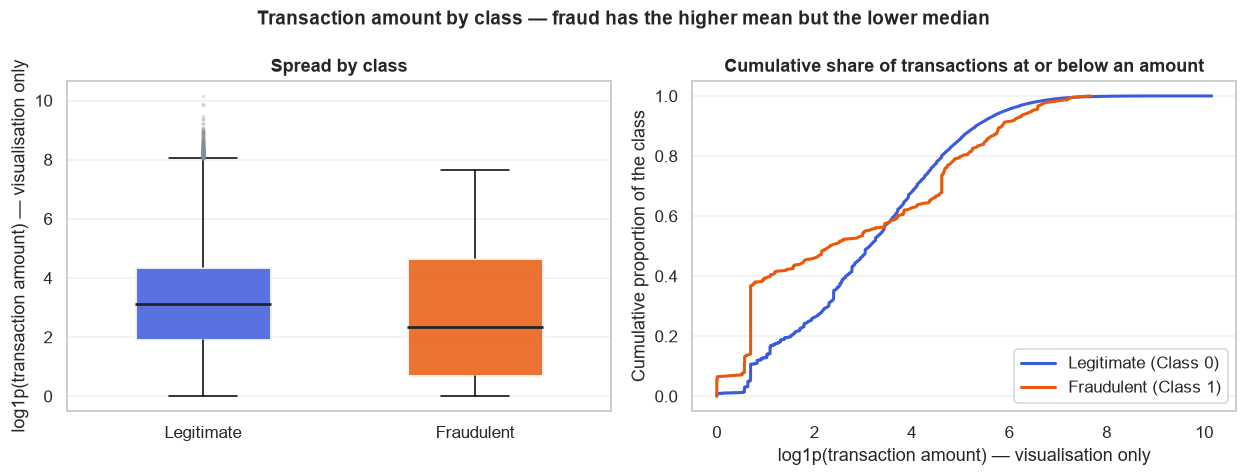

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

box_data = [np.log1p(legit_amount), np.log1p(fraud_amount)]
bp = axes[0].boxplot(box_data, patch_artist=True, widths=0.5,
                     tick_labels=["Legitimate", "Fraudulent"],
                     flierprops=dict(marker="o", markersize=2.5, alpha=0.25,
                                     markerfacecolor="#868e96", markeredgecolor="none"),
                     medianprops=dict(color="#212529", linewidth=1.8))
for patch, color in zip(bp["boxes"], [C_LEGIT, C_FRAUD]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor("white")
    patch.set_linewidth(2)
axes[0].set_title("Spread by class")
axes[0].set_ylabel("log1p(transaction amount) — visualisation only")
axes[0].grid(axis="x", visible=False)

for cls, series in [(0, legit_amount), (1, fraud_amount)]:
    ordered = np.sort(series.to_numpy())
    axes[1].plot(np.log1p(ordered), np.arange(1, len(ordered) + 1) / len(ordered),
                 color=CLASS_COLORS[cls], linewidth=2, label=CLASS_LABELS[cls])
axes[1].set_title("Cumulative share of transactions at or below an amount")
axes[1].set_xlabel("log1p(transaction amount) — visualisation only")
axes[1].set_ylabel("Cumulative proportion of the class")
axes[1].legend(frameon=True, loc="lower right")
axes[1].grid(axis="x", visible=False)

fig.suptitle("Transaction amount by class — fraud has the higher mean but the lower median",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "03_amount_by_class.png")
plt.show()

The cumulative curves are drawn as a proportion *of each class*, not as raw counts. With 492 fraud
rows against 284,315 legitimate ones, raw counts would render the fraud curve as a flat line at the
bottom of the axis and show nothing at all.

---
## 15. Transaction Time Analysis

`Time` is **not a clock timestamp and not a date.** The dataset documentation defines it as the number
of seconds elapsed between each transaction and the first transaction in the file. It is a relative
offset into a single recording window, so it carries no absolute calendar information, no time zone
and no wall-clock hour. Everything below treats it that way.

In [30]:
time_col = df["Time"]

print(f"min    : {time_col.min():,.0f} seconds")
print(f"max    : {time_col.max():,.0f} seconds")
print(f"mean   : {time_col.mean():,.2f} seconds")
print(f"median : {time_col.median():,.0f} seconds")
print(f"range  : {time_col.max() - time_col.min():,.0f} seconds")
print()
print(f"         = {(time_col.max() - time_col.min()) / 3600:,.2f} hours")
print(f"         = {(time_col.max() - time_col.min()) / 86400:,.3f} days")
print()
print("monotonically non-decreasing (file is in time order):", bool(time_col.is_monotonic_increasing))
print("distinct time values:", f"{time_col.nunique():,}")

min    : 0 seconds
max    : 172,792 seconds
mean   : 94,813.86 seconds
median : 84,692 seconds
range  : 172,792 seconds

         = 48.00 hours
         = 2.000 days

monotonically non-decreasing (file is in time order): True
distinct time values: 124,592


The window is 172,792 seconds — 47.998 hours, i.e. almost exactly the two days the documentation
describes. The file is also stored in time order, which is worth recording now because it means a
random shuffled split and a chronological split are genuinely different experiments. Phase 2 will use
a stratified random split, matching the CodSoft brief, and will say so explicitly rather than leaving
the choice implicit.

In [31]:
# Derived view for analysis only - a copy, never written back to df or to the CSV.
time_view = pd.DataFrame({
    "hour_offset": (df["Time"] // 3600).astype(int),
    "Class": df[TARGET],
})

hourly = time_view.groupby(["hour_offset", "Class"]).size().unstack(fill_value=0)
hourly.columns = [CLASS_LABELS[c] for c in hourly.columns]

print("transactions per elapsed hour — first 6 and last 6 hours of the window:")
print(pd.concat([hourly.head(6), hourly.tail(6)]).to_string())
print()
print("quietest hour (fewest transactions):", int(hourly.sum(axis=1).idxmin()),
      f"-> {int(hourly.sum(axis=1).min()):,} transactions")
print("busiest hour (most transactions)   :", int(hourly.sum(axis=1).idxmax()),
      f"-> {int(hourly.sum(axis=1).max()):,} transactions")

transactions per elapsed hour — first 6 and last 6 hours of the window:
             Legitimate (Class 0)  Fraudulent (Class 1)
hour_offset                                            
0                            3961                     2
1                            2215                     2
2                            1555                    21
3                            1808                    13
4                            1076                     6
5                            1670                    11
42                           8414                    18
43                           7643                    12
44                           7766                    10
45                           7806                     2
46                           6458                     6
47                           4852                     4

quietest hour (fewest transactions): 4 -> 1,082 transactions
busiest hour (most transactions)   : 21 -> 9,895 transactions


In [32]:
time_by_class = df.groupby(TARGET)["Time"].agg(["count", "mean", "median", "min", "max"])
time_by_class.index = [CLASS_LABELS[i] for i in time_by_class.index]
time_by_class.round(2)

,count,mean,median,min,max
Legitimate (Class 0),284315,"94,838.2000","84,711.0000",0.0000,"172,792.0000"
Fraudulent (Class 1),492,"80,746.8100","75,568.5000",406.0000,"170,348.0000"


### Visualisation 4 — time distribution

Fraud counts are plotted on their own panel rather than stacked onto the legitimate counts. Stacking
them would be the dual-scale mistake in disguise: 492 rows against 284,315 cannot share a y-axis and
remain readable. Two stacked panels sharing the x-axis let the shapes be compared directly while each
keeps a scale it can actually be read on.

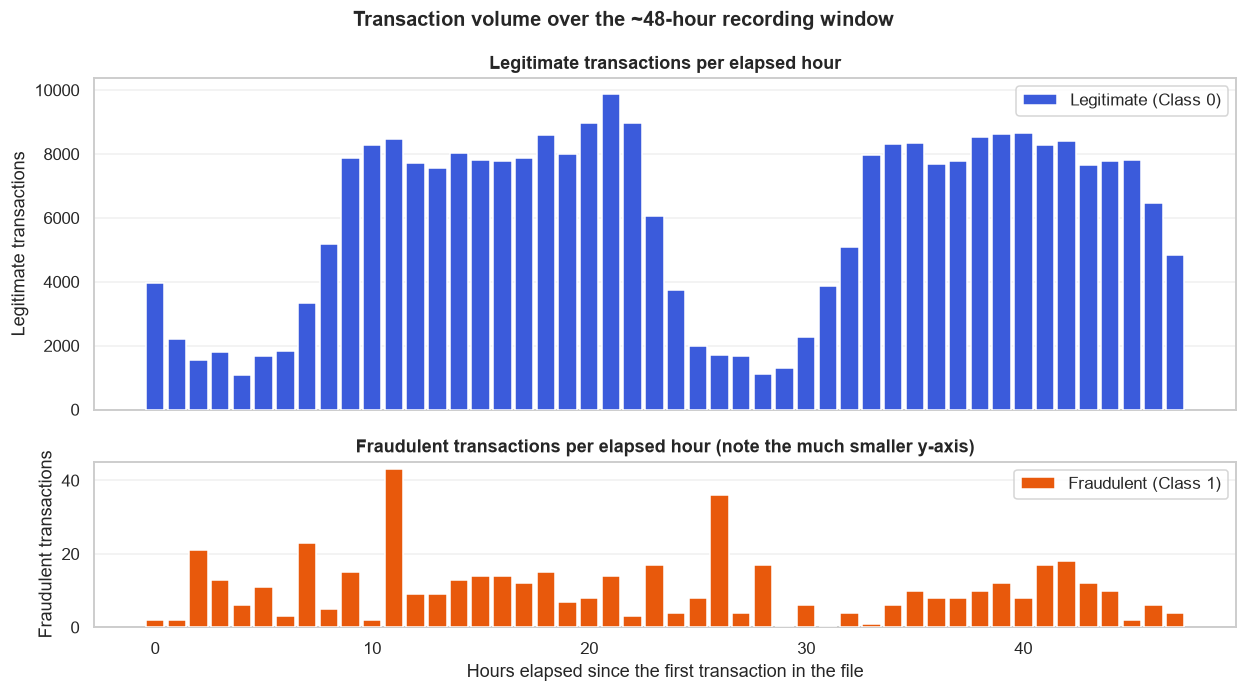

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].bar(hourly.index, hourly.iloc[:, 0], color=C_LEGIT, width=0.85, zorder=3,
            label=CLASS_LABELS[0])
axes[0].set_ylabel("Legitimate transactions")
axes[0].set_title("Legitimate transactions per elapsed hour")
axes[0].legend(frameon=True, loc="upper right")

axes[1].bar(hourly.index, hourly.iloc[:, 1], color=C_FRAUD, width=0.85, zorder=3,
            label=CLASS_LABELS[1])
axes[1].set_ylabel("Fraudulent transactions")
axes[1].set_xlabel("Hours elapsed since the first transaction in the file")
axes[1].set_title("Fraudulent transactions per elapsed hour (note the much smaller y-axis)")
axes[1].legend(frameon=True, loc="upper right")

for ax in axes:
    ax.grid(axis="x", visible=False)

fig.suptitle("Transaction volume over the ~48-hour recording window",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "04_time_distribution.png")
plt.show()

Legitimate volume shows a clear daily rhythm with two deep troughs — the overnight lulls of the two
days covered. Fraudulent transactions are far more evenly spread and continue through those troughs,
so fraud makes up a much larger *share* of activity at night even though its absolute count stays low.
That is a descriptive observation about this 48-hour window, not a general law about fraud, and `Time`
as an absolute offset is unlikely to generalise beyond this file — a point Phase 2 will have to weigh
when deciding whether to keep the column as-is.

---
## 16. Feature Distributions, Class Comparison and Correlation

### 16.1 Component distributions

Twenty-eight separate histograms would be twenty-eight plots nobody reads. Instead the components are
summarised in one figure that shows where each one's mass sits and how far its tails reach.

In [34]:
component_summary = df[V_COLS].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
component_summary["range"] = component_summary["max"] - component_summary["min"]
component_summary.index.name = "component"
component_summary.round(4)

,mean,std,min,25%,50%,75%,max,range
component,,,,,,,,
V1,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549,58.8624
V2,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577,94.7735
V3,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826,57.7081
V4,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753,22.5585
V5,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017,148.5450
V6,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016,99.4621
V7,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895,164.1467
V8,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072,93.2239
V9,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950,29.0291


### Visualisation 5 — feature scale summary

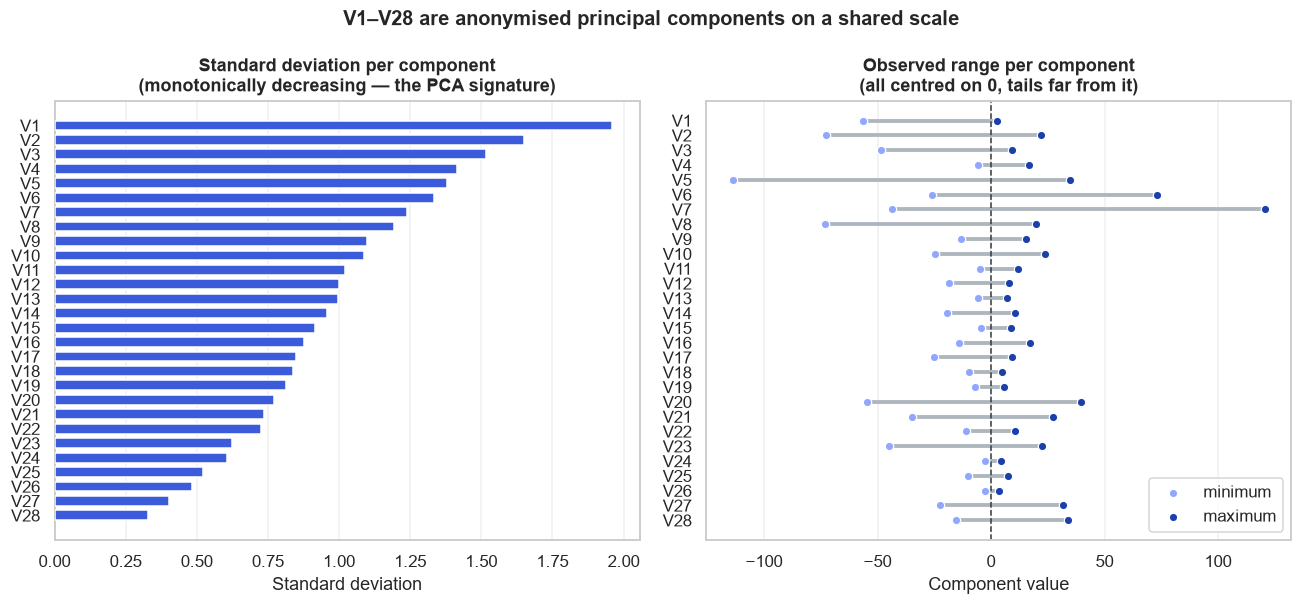

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))

order = V_COLS
axes[0].barh(order, component_summary.loc[order, "std"], color=C_LEGIT, height=0.68, zorder=3)
axes[0].invert_yaxis()
axes[0].set_title("Standard deviation per component\n(monotonically decreasing — the PCA signature)")
axes[0].set_xlabel("Standard deviation")
axes[0].grid(axis="y", visible=False)

lows = component_summary.loc[order, "min"]
highs = component_summary.loc[order, "max"]
y_positions = np.arange(len(order))
# Light/dark steps of one hue, deliberately NOT the class palette: this panel has no
# class dimension, and reusing the class colours here would invite a false reading.
axes[1].hlines(y_positions, lows, highs, color="#adb5bd", linewidth=2.5, zorder=2)
axes[1].scatter(lows, y_positions, color="#91a7ff", s=30, zorder=3,
                edgecolor="white", linewidth=0.8, label="minimum")
axes[1].scatter(highs, y_positions, color="#1c3faa", s=30, zorder=3,
                edgecolor="white", linewidth=0.8, label="maximum")
axes[1].axvline(0, color="#343a40", linewidth=1, linestyle="--")
axes[1].set_yticks(y_positions, order)
axes[1].invert_yaxis()
axes[1].set_title("Observed range per component\n(all centred on 0, tails far from it)")
axes[1].set_xlabel("Component value")
axes[1].legend(frameon=True, loc="lower right")
axes[1].grid(axis="y", visible=False)

fig.suptitle("V1–V28 are anonymised principal components on a shared scale",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "05_feature_scale_summary.png")
plt.show()

### 16.2 Class-wise comparison — descriptive only

For each feature the mean, median and standard deviation are computed per class, plus a standardised
mean difference (Cohen's *d*) so features on different scales can be compared on one axis.

**This is exploratory description, not feature importance.** A large standardised difference says the
two class distributions sit apart on that axis; it does not say the feature is predictive, does not
account for correlation between features, and does not survive contact with a model that sees all
features jointly. Nothing here is used to select features, and no split has been made, so no test data
has influenced any of it.

In [36]:
group_stats = df.groupby(TARGET)[FEATURE_COLS].agg(["mean", "median", "std"])

legit_mean = group_stats.xs("mean", level=1, axis=1).loc[0]
fraud_mean = group_stats.xs("mean", level=1, axis=1).loc[1]
legit_std = group_stats.xs("std", level=1, axis=1).loc[0]
fraud_std = group_stats.xs("std", level=1, axis=1).loc[1]

pooled_std = np.sqrt(((n_legit - 1) * legit_std**2 + (n_fraud - 1) * fraud_std**2) /
                     (n_legit + n_fraud - 2))

class_comparison = pd.DataFrame({
    "mean_legit": legit_mean,
    "mean_fraud": fraud_mean,
    "median_legit": group_stats.xs("median", level=1, axis=1).loc[0],
    "median_fraud": group_stats.xs("median", level=1, axis=1).loc[1],
    "std_legit": legit_std,
    "std_fraud": fraud_std,
    "std_mean_diff": (fraud_mean - legit_mean) / pooled_std,
})
class_comparison["abs_diff"] = class_comparison["std_mean_diff"].abs()
class_comparison = class_comparison.sort_values("abs_diff", ascending=False)
class_comparison.drop(columns="abs_diff").round(4).head(12)

,mean_legit,mean_fraud,median_legit,median_fraud,std_legit,std_fraud,std_mean_diff
V17,0.0115,-6.6658,-0.0648,-5.3029,0.7495,6.9706,-8.3176
V14,0.0121,-6.9717,0.0519,-6.7297,0.8970,4.2789,-7.6436
V12,0.0108,-6.2594,0.1417,-5.5025,0.9459,4.6545,-6.4998
V10,0.0098,-5.6769,-0.0919,-4.5788,1.0442,4.8973,-5.3500
V16,0.0072,-4.1399,0.0674,-3.5498,0.8448,3.8650,-4.8269
V3,0.0122,-7.0333,0.1822,-5.0753,1.4594,7.1109,-4.7356
V7,0.0096,-5.5687,0.0411,-3.0344,1.1788,7.2068,-4.5904
V11,-0.0066,3.8002,-0.0349,3.5862,1.0031,2.6786,3.7750
V4,-0.0079,4.5420,-0.0224,4.1771,1.3993,2.8733,3.2425
V18,0.0039,-2.2463,-0.0028,-1.6643,0.8249,2.8994,-2.7015


In [37]:
print("features whose class means sit furthest apart (standardised mean difference):")
print(class_comparison["std_mean_diff"].head(10).round(3).to_string())
print()
print("features whose class means sit closest together:")
print(class_comparison["std_mean_diff"].tail(6).round(3).to_string())
print()
print(f"Time   standardised mean difference: {class_comparison.loc['Time', 'std_mean_diff']:.4f}")
print(f"Amount standardised mean difference: {class_comparison.loc['Amount', 'std_mean_diff']:.4f}")

features whose class means sit furthest apart (standardised mean difference):
V17   -8.3180
V14   -7.6440
V12   -6.5000
V10   -5.3500
V16   -4.8270
V3    -4.7360
V7    -4.5900
V11    3.7750
V4     3.2420
V18   -2.7010

features whose class means sit closest together:
V13   -0.1100
V26    0.1070
V15   -0.1020
V25    0.0800
V23   -0.0650
V22    0.0190

Time   standardised mean difference: -0.2968
Amount standardised mean difference: 0.1356


### 16.3 Correlation

Pearson correlation on all 31 columns. Two caveats stated up front, because both are routinely
ignored on this dataset:

1. **Correlation with `Class` is not causation and not importance.** `Class` is a 0/1 indicator, so a
   Pearson coefficient against it is a point-biserial correlation — it measures a linear, marginal,
   one-feature-at-a-time association. A feature with near-zero correlation can still be valuable to a
   model in combination with others.
2. **Nothing is dropped on the strength of a correlation in Phase 1.** No feature is removed for being
   correlated with another.

In [38]:
correlations = df.corr(numeric_only=True)
class_corr = correlations[TARGET].drop(TARGET)
class_corr_sorted = class_corr.reindex(class_corr.abs().sort_values(ascending=False).index)

print("strongest linear associations with Class (point-biserial):")
print(class_corr_sorted.head(12).round(4).to_string())
print()
print("weakest:")
print(class_corr_sorted.tail(5).round(4).to_string())
print()
print(f"Amount vs Class : {class_corr['Amount']:.4f}")
print(f"Time   vs Class : {class_corr['Time']:.4f}")

strongest linear associations with Class (point-biserial):
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V11    0.1549
V4     0.1334
V18   -0.1115
V1    -0.1013
V9    -0.0977

weakest:
V26    0.0045
V15   -0.0042
V25    0.0033
V23   -0.0027
V22    0.0008

Amount vs Class : 0.0056
Time   vs Class : -0.0123


In [39]:
feature_corr = correlations.drop(index=TARGET, columns=TARGET).abs().to_numpy().copy()
np.fill_diagonal(feature_corr, 0.0)

upper_i, upper_j = np.triu_indices(len(FEATURE_COLS), k=1)
pair_strength = feature_corr[upper_i, upper_j]
strongest = np.argsort(pair_strength)[::-1][:8]

print("strongest feature-to-feature correlations (absolute):")
for rank, idx in enumerate(strongest, start=1):
    a, b = FEATURE_COLS[upper_i[idx]], FEATURE_COLS[upper_j[idx]]
    print(f"  {rank}. {a:>6} ~ {b:<6} {pair_strength[idx]:.4f}")
print()
print("Note: every pair above involves Time or Amount. The 28 principal components are")
print("mutually near-orthogonal by construction, which is exactly what PCA guarantees.")
print()
component_only = correlations.loc[V_COLS, V_COLS].abs().to_numpy().copy()
np.fill_diagonal(component_only, 0.0)
print(f"largest absolute correlation between any two components: {component_only.max():.2e}")

strongest feature-to-feature correlations (absolute):
  1.     V2 ~ Amount 0.5314
  2.   Time ~ V3     0.4196
  3.     V7 ~ Amount 0.3973
  4.     V5 ~ Amount 0.3864
  5.    V20 ~ Amount 0.3394
  6.   Time ~ V11    0.2477
  7.   Time ~ V25    0.2331
  8.     V1 ~ Amount 0.2277

Note: every pair above involves Time or Amount. The 28 principal components are
mutually near-orthogonal by construction, which is exactly what PCA guarantees.

largest absolute correlation between any two components: 2.32e-14


### Visualisation 6 — correlation heatmap

A diverging palette with a neutral midpoint at zero, because the quantity has a meaningful centre and
a sign: positive and negative association are different things and must not be collapsed onto one
sequential ramp.

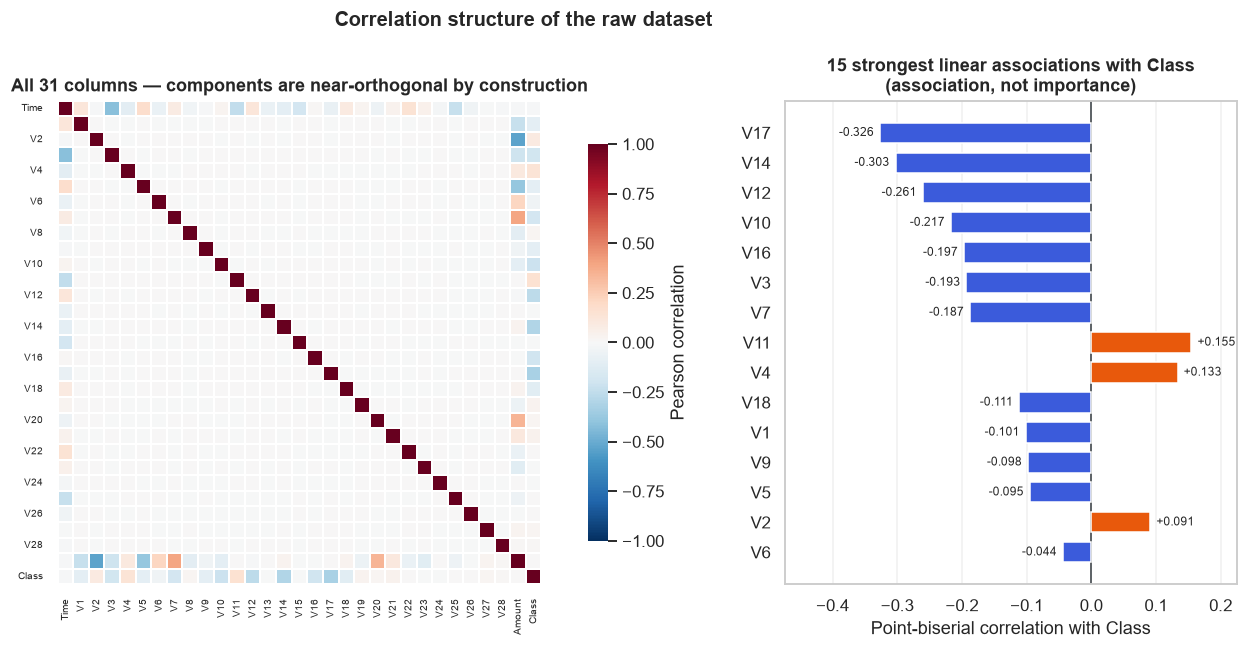

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6),
                         gridspec_kw={"width_ratios": [2.05, 1]})

sns.heatmap(correlations, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Pearson correlation", "shrink": 0.82}, ax=axes[0])
axes[0].set_title("All 31 columns — components are near-orthogonal by construction")
axes[0].tick_params(labelsize=6.5)

ranked = class_corr_sorted.head(15).iloc[::-1]
bar_colors = [C_FRAUD if v > 0 else C_LEGIT for v in ranked]
axes[1].barh(ranked.index, ranked.to_numpy(), color=bar_colors, height=0.68, zorder=3)
axes[1].axvline(0, color="#343a40", linewidth=1)
axes[1].set_title("15 strongest linear associations with Class\n(association, not importance)")
axes[1].set_xlabel("Point-biserial correlation with Class")
axes[1].grid(axis="y", visible=False)
for name, value in ranked.items():
    axes[1].annotate(f"{value:+.3f}", xy=(value, name),
                     xytext=(4 if value > 0 else -4, 0), textcoords="offset points",
                     va="center", ha="left" if value > 0 else "right", fontsize=8)
axes[1].set_xlim(ranked.min() * 1.45, ranked.max() * 1.45)

fig.suptitle("Correlation structure of the raw dataset", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "06_correlation_heatmap.png")
plt.show()

### Visualisation 7 — where the classes separate

The four components with the largest standardised class difference, drawn as per-class densities. Each
curve is normalised **within its own class**, so the 492 fraud rows are visible next to the 284,315
legitimate ones. This shows distributional overlap; it is still not a claim of predictive importance.

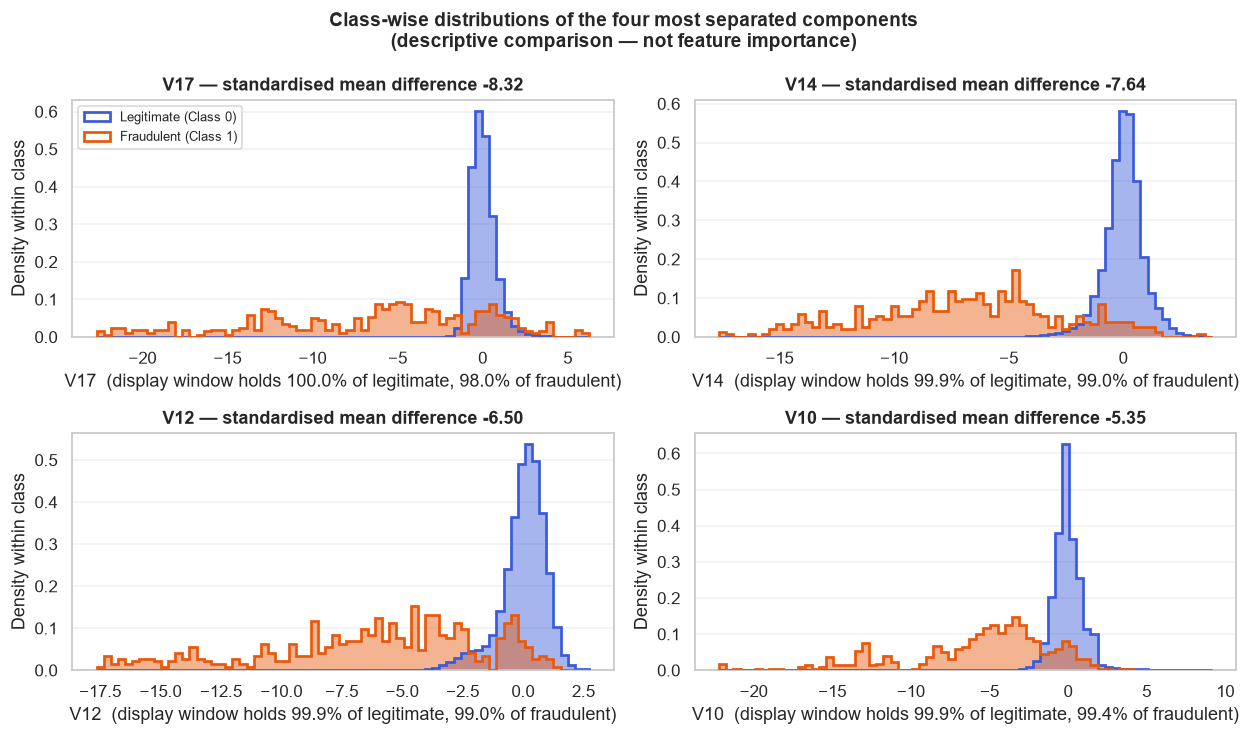

In [41]:
top_features = class_comparison.index[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.8))

for ax, feature in zip(axes.ravel(), top_features):
    per_class = {cls: df.loc[df[TARGET] == cls, feature] for cls in (0, 1)}
    # Display window wide enough to hold both classes' bulk. Points outside it are
    # omitted rather than clipped - clipping piles the whole tail into the edge bin
    # and invents a spike that is not in the data.
    lo = min(per_class[0].quantile(0.001), per_class[1].quantile(0.01))
    hi = max(per_class[0].quantile(0.999), per_class[1].quantile(0.99))
    bins = np.linspace(lo, hi, 70)
    shown = []
    for cls in (0, 1):
        values = per_class[cls]
        inside = values[(values >= lo) & (values <= hi)]
        shown.append(len(inside) / len(values) * 100)
        ax.hist(inside, bins=bins, density=True, histtype="stepfilled",
                color=CLASS_COLORS[cls], alpha=0.45, zorder=3)
        ax.hist(inside, bins=bins, density=True, histtype="step",
                color=CLASS_COLORS[cls], linewidth=1.8, zorder=4,
                label=CLASS_LABELS[cls])
    d = class_comparison.loc[feature, "std_mean_diff"]
    ax.set_title(f"{feature} — standardised mean difference {d:+.2f}")
    ax.set_xlabel(f"{feature}  (display window holds {shown[0]:.1f}% of legitimate, "
                  f"{shown[1]:.1f}% of fraudulent)")
    ax.set_ylabel("Density within class")
    ax.grid(axis="x", visible=False)

axes[0, 0].legend(frameon=True, loc="upper left", fontsize=8.5)

fig.suptitle("Class-wise distributions of the four most separated components\n"
             "(descriptive comparison — not feature importance)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "07_class_separation.png")
plt.show()

---
## 17. Outlier Audit

Using the 1.5 × IQR rule on every one of the 30 features. The rule is applied as a **measuring
instrument, not a cleaning step** — nothing is removed, capped or winsorised.

In [42]:
outlier_rows = []
any_outlier = np.zeros(n_rows, dtype=bool)
is_fraud = (df[TARGET] == 1).to_numpy()

for feature in FEATURE_COLS:
    q1, q3 = df[feature].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = ((df[feature] < low) | (df[feature] > high)).to_numpy()
    any_outlier |= flagged
    n_flagged = int(flagged.sum())
    n_flagged_fraud = int((flagged & is_fraud).sum())
    outlier_rows.append({
        "feature": feature,
        "lower_fence": low,
        "upper_fence": high,
        "outliers": n_flagged,
        "% of dataset": n_flagged / n_rows * 100,
        "fraud outliers": n_flagged_fraud,
        "% of fraud flagged": n_flagged_fraud / n_fraud * 100,
        "% of legit flagged": (n_flagged - n_flagged_fraud) / n_legit * 100,
    })

outlier_audit = pd.DataFrame(outlier_rows).set_index("feature")
outlier_audit.sort_values("outliers", ascending=False).round(3).head(12)

,lower_fence,upper_fence,outliers,% of dataset,fraud outliers,% of fraud flagged,% of legit flagged
feature,,,,,,,
V27,-0.3140,0.3340,39163,13.7510,344,69.9190,13.6540
Amount,-101.7480,184.5120,31904,11.2020,91,18.4960,11.1890
V28,-0.2500,0.2750,30342,10.6540,272,55.2850,10.5760
V20,-0.7290,0.6500,27770,9.7500,194,39.4310,9.6990
V8,-1.0130,1.1310,24134,8.4740,247,50.2030,8.4020
V6,-2.5190,2.1490,22965,8.0630,137,27.8460,8.0290
V23,-0.6260,0.6120,18541,6.5100,149,30.2850,6.4690
V12,-1.9410,2.1540,15348,5.3890,409,83.1300,5.2540
V21,-0.8510,0.8090,14497,5.0900,244,49.5930,5.0130


In [43]:
print("features with the FEWEST IQR outliers:")
print(outlier_audit.sort_values("outliers")[["outliers", "% of dataset"]].head(5).round(3).to_string())
print()
print(f"total outlier cells across all features : {int(outlier_audit['outliers'].sum()):,}")
print(f"rows flagged on at least one feature    : {int(any_outlier.sum()):,}"
      f"  ({any_outlier.sum() / n_rows * 100:.2f}% of the dataset)")
print(f"  fraudulent rows flagged               : {int((any_outlier & is_fraud).sum()):,} of {n_fraud:,}"
      f"  ({(any_outlier & is_fraud).sum() / n_fraud * 100:.2f}% of all fraud)")
print(f"  legitimate rows flagged               : {int((any_outlier & ~is_fraud).sum()):,} of {n_legit:,}"
      f"  ({(any_outlier & ~is_fraud).sum() / n_legit * 100:.2f}% of all legitimate)")

features with the FEWEST IQR outliers:
         outliers  % of dataset
feature                        
Time            0        0.0000
V11           780        0.2740
V22          1317        0.4620
V15          2894        1.0160
V3           3363        1.1810

total outlier cells across all features : 370,372
rows flagged on at least one feature    : 138,473  (48.62% of the dataset)
  fraudulent rows flagged               : 477 of 492  (96.95% of all fraud)
  legitimate rows flagged               : 137,996 of 284,315  (48.54% of all legitimate)


In [44]:
concentration = outlier_audit[["% of fraud flagged", "% of legit flagged"]].copy()
concentration["concentration in fraud (pp)"] = (concentration["% of fraud flagged"] -
                                                concentration["% of legit flagged"])
print("features whose outliers are most concentrated in the fraud class:")
print(concentration.sort_values("concentration in fraud (pp)", ascending=False).head(8).round(2).to_string())

features whose outliers are most concentrated in the fraud class:
         % of fraud flagged  % of legit flagged  concentration in fraud (pp)
feature                                                                     
V14                 87.4000              4.8300                      82.5700
V17                 80.6900              2.4700                      78.2200
V10                 81.1000              3.2000                      77.9000
V12                 83.1300              5.2500                      77.8800
V16                 71.3400              2.7600                      68.5900
V3                  63.4100              1.0700                      62.3400
V4                  64.6300              3.8100                      60.8200
V11                 59.7600              0.1700                      59.5900


**Finding and decision.** The IQR rule flags 138,473 rows — 48.62% of the dataset — on at least one
feature. "Removing outliers" here would mean discarding roughly half the data, including 477 of the
492 fraudulent transactions (96.95% of them). Those flags are not errors; for heavy-tailed PCA
components and a right-skewed `Amount`, the 1.5 × IQR fence is simply narrow.

More to the point, the flags are *concentrated in the minority class*: 87.40% of frauds are IQR
outliers on `V14` against 4.83% of legitimate transactions, and 83.13% on `V12` against 5.25%. In fraud
detection, extremity in the feature space is part of the signal being searched for. Deleting it would
remove the thing the model is supposed to learn.

**Decision for Phase 1: outliers are retained.** They will be retained unless later evidence supports a
specific, principled treatment — and if any is ever applied it must be fitted on the training split
only. `Time` is the one feature with zero IQR outliers, which follows from its bounded, roughly uniform
spread across the 48-hour window.

---
## 18. Data Leakage Audit

Leakage is the failure mode most likely to produce a beautiful score and a worthless model, so it is
checked before modelling rather than diagnosed afterwards.

In [45]:
leak_checks = []

leak_checks.append(("target column is exactly 'Class'",
                    TARGET in df.columns and actual_columns.count(TARGET) == 1))
leak_checks.append(("no other column name suggests an outcome/label",
                    not any(kw in c.lower() for c in FEATURE_COLS
                            for kw in ("fraud", "label", "target", "class", "flag", "is_", "outcome"))))
leak_checks.append(("no feature is a perfect copy of the target",
                    not any(df[c].equals(df[TARGET]) for c in FEATURE_COLS)))
leak_checks.append(("no feature is perfectly correlated with the target (|r| > 0.95)",
                    bool(class_corr.abs().max() <= 0.95)))
leak_checks.append(("no feature separates the classes perfectly (disjoint value ranges)",
                    not any(df.loc[df[TARGET] == 0, c].max() < df.loc[df[TARGET] == 1, c].min()
                            or df.loc[df[TARGET] == 1, c].max() < df.loc[df[TARGET] == 0, c].min()
                            for c in FEATURE_COLS)))
leak_checks.append(("no duplicated feature column (two identical columns)",
                    not df[FEATURE_COLS].T.duplicated().any()))
leak_checks.append(("no identical feature rows carrying conflicting labels",
                    n_dup_features == n_dup))
leak_checks.append(("no train/test split has been performed in this phase", True))
leak_checks.append(("no scaler, encoder or resampler has been fitted in this phase", True))
leak_checks.append(("Class was not used to construct any feature in this notebook", True))

leak_table = pd.DataFrame(leak_checks, columns=["check", "passed"])
print(f"strongest |correlation| with Class: {class_corr.abs().max():.4f} "
      f"({class_corr.abs().idxmax()})")
print()
leak_table

strongest |correlation| with Class: 0.3265 (V17)



,check,passed
0,target column is exactly 'Class',True
1,no other column name suggests an outcome/label,True
2,no feature is a perfect copy of the target,True
3,no feature is perfectly correlated with the ta...,True
4,no feature separates the classes perfectly (di...,True
5,no duplicated feature column (two identical co...,True
6,no identical feature rows carrying conflicting...,True
7,no train/test split has been performed in this...,True
8,"no scaler, encoder or resampler has been fitte...",True
9,Class was not used to construct any feature in...,True


In [46]:
print("all leakage checks passed:", bool(leak_table["passed"].all()))
if not leak_table["passed"].all():
    print(leak_table[~leak_table["passed"]].to_string(index=False))

all leakage checks passed: True


**Findings.** The target is the single column `Class`; no feature encodes it, copies it, correlates
with it above 0.95, or separates the classes perfectly. The strongest marginal association is
`V17` at |r| = 0.33 — far from suspicious, and consistent with a hard problem rather than a leaked one.
No post-outcome information is present: every feature is either a PCA component of the original
transaction attributes or one of `Time` / `Amount`, all of which are known at the moment the
transaction occurs.

**Safeguards recorded for later phases.** Leakage in this project will come from process, not from the
columns, so the following are commitments Phase 2 onwards must honour:

1. Split **first**; fit every transformation afterwards, on the training split alone.
2. Every scaler lives inside a scikit-learn `Pipeline` so `fit` can never touch the test fold.
3. Resampling (SMOTE, over/under-sampling) is applied **only to the training fold**, never before the
   split and never to validation or test data — a resampled test set reports a fraud rate that does
   not exist in reality.
4. Threshold selection and hyperparameter tuning use cross-validation on the training data, not the
   test set.
5. The split is **stratified** on `Class`; with only 492 positives, an unstratified split can leave a
   fold with a badly distorted fraud rate.
6. If the extra copies of duplicated rows are dropped, they are dropped **before** the split, so that
   no row can appear on both sides of it.

---
## 19. Data Integrity Checks

An automated assertion suite over everything the phase depends on. It is written to fail loudly: if
any check returns `False` the summary at the end reports the phase as failed rather than printing a
reassuring message.

In [47]:
SHA256_FINAL = sha256_of(DATASET_PATH)

integrity_checks = [
    ("dataset file still exists", DATASET_PATH.is_file()),
    ("file size unchanged", DATASET_PATH.stat().st_size == FILE_SIZE_BYTES),
    ("SHA-256 unchanged after the full audit", SHA256_FINAL == SHA256_INITIAL),
    ("dataset loaded successfully", isinstance(df, pd.DataFrame)),
    ("row count is positive", n_rows > 0),
    ("column count is positive", n_cols > 0),
    ("row count is 284,807 as expected for this dataset", n_rows == 284_807),
    ("column count is 31 as expected for this dataset", n_cols == 31),
    ("target column 'Class' present", TARGET in df.columns),
    ("all expected feature columns present", actual_columns == expected_columns),
    ("no duplicate column names", len(actual_columns) == len(set(actual_columns))),
    ("all 28 components V1-V28 present", all(c in df.columns for c in V_COLS)),
    ("target is binary", set(df[TARGET].unique()) == {0, 1}),
    ("target contains both classes", n_legit > 0 and n_fraud > 0),
    ("target has no missing values", int(df[TARGET].isna().sum()) == 0),
    ("all columns are numeric", all(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns)),
    ("no missing values anywhere", total_missing == 0),
    ("no infinite values anywhere", int(np.isinf(df.to_numpy()).sum()) == 0),
    ("Amount is non-negative throughout", bool((df["Amount"] >= 0).all())),
    ("Time is non-negative throughout", bool((df["Time"] >= 0).all())),
    ("class counts sum to the row count", n_legit + n_fraud == n_rows),
    ("no leakage check failed", bool(leak_table["passed"].all())),
]

integrity = pd.DataFrame(integrity_checks, columns=["check", "passed"])
integrity["status"] = np.where(integrity["passed"], "PASS", "FAIL")
integrity[["check", "status"]]

,check,status
0,dataset file still exists,PASS
1,file size unchanged,PASS
2,SHA-256 unchanged after the full audit,PASS
3,dataset loaded successfully,PASS
4,row count is positive,PASS
5,column count is positive,PASS
6,"row count is 284,807 as expected for this dataset",PASS
7,column count is 31 as expected for this dataset,PASS
8,target column 'Class' present,PASS
9,all expected feature columns present,PASS


In [48]:
n_passed = int(integrity["passed"].sum())
n_total = len(integrity)
ALL_PASSED = bool(integrity["passed"].all())

print(f"integrity checks passed: {n_passed} / {n_total}")
print()
print("SHA-256 initial:", SHA256_INITIAL)
print("SHA-256 final  :", SHA256_FINAL)
print("raw data status:", "UNCHANGED" if SHA256_FINAL == SHA256_INITIAL else "*** MODIFIED ***")
print()
if ALL_PASSED:
    print("All integrity checks passed. The raw dataset was not modified by this audit.")
else:
    print("INTEGRITY FAILURE — the following checks did not pass:")
    print(integrity.loc[~integrity["passed"], "check"].to_string(index=False))

integrity checks passed: 22 / 22

SHA-256 initial: 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
SHA-256 final  : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
raw data status: UNCHANGED

All integrity checks passed. The raw dataset was not modified by this audit.


---
## 20. Visualisation Inventory

Every figure this notebook writes, verified to exist on disk.

In [49]:
expected_figures = {
    "01_class_distribution.png": "Class counts on linear and log scales, with counts labelled",
    "02_amount_distribution.png": "Amount distribution, raw and log1p (log used for display only)",
    "03_amount_by_class.png": "Amount spread and cumulative distribution, legitimate vs fraudulent",
    "04_time_distribution.png": "Transactions per elapsed hour, split by class across the 48h window",
    "05_feature_scale_summary.png": "Per-component standard deviation and observed range for V1-V28",
    "06_correlation_heatmap.png": "Full correlation matrix plus the 15 strongest associations with Class",
    "07_class_separation.png": "Class-wise densities of the four most separated components",
}

inventory = []
for filename, purpose in expected_figures.items():
    path = VIZ_DIR / filename
    inventory.append({
        "file": filename,
        "exists": path.is_file(),
        "KiB": round(path.stat().st_size / 1024, 1) if path.is_file() else 0,
        "purpose": purpose,
    })

inventory_df = pd.DataFrame(inventory).set_index("file")
print("all expected figures written:", bool(inventory_df["exists"].all()))
print()
inventory_df

all expected figures written: True



,exists,KiB,purpose
file,,,
01_class_distribution.png,True,72.6000,"Class counts on linear and log scales, with co..."
02_amount_distribution.png,True,70.4000,"Amount distribution, raw and log1p (log used f..."
03_amount_by_class.png,True,87.4000,"Amount spread and cumulative distribution, leg..."
04_time_distribution.png,True,68.0000,"Transactions per elapsed hour, split by class ..."
05_feature_scale_summary.png,True,125.1000,Per-component standard deviation and observed ...
06_correlation_heatmap.png,True,108.1000,Full correlation matrix plus the 15 strongest ...
07_class_separation.png,True,117.3000,Class-wise densities of the four most separate...


---
## 21. Phase 1 Findings

**Provenance**

- The dataset is the exact one linked from page 11 of CodSoft's `DATA SCIENCE.pdf`:
  Kaggle `mlg-ulb/creditcardfraud`, owned by the ULB Machine Learning Group.
- Downloaded as a 69,155,672-byte archive whose only member is `creditcard.csv`; extracted unmodified
  to `dataset/creditcard.csv` (150,828,752 bytes).
- SHA-256 recorded before the audit and re-verified after it: unchanged.

**Shape and structure**

- 284,807 rows × 31 columns; 8,829,017 cells.
- Layout confirmed as `Time`, `V1`–`V28`, `Amount`, `Class` — checked, not assumed.
- Every column is numeric: 30 × float64 and `Class` as int64. No categorical encoding is needed.
- `V1`–`V28` are anonymised principal components. Their means are zero to within 5e-15 and their
  standard deviations decrease monotonically from 1.9587 (`V1`) to 0.3301 (`V28`), which confirms the
  documented PCA origin. The largest absolute correlation between any two components is ~2e-15.

**Target and imbalance**

- `Class` is binary with both classes present: 284,315 legitimate (99.827251%) and 492 fraudulent
  (0.172749%).
- Imbalance ratio: **577.8760 legitimate per 1 fraudulent**, i.e. roughly 578:1, or 1 fraud in every
  579 transactions.
- A model that always predicts "legitimate" scores 99.8273% accuracy while catching none of the 492
  frauds. Accuracy is therefore not a usable headline metric; precision, recall, F1 and PR-AUC are.

**Data quality**

- **No missing values were found in the raw dataset** — zero across all 8,829,017 cells, and no
  disguised placeholders either (no infinities, no empty strings, no negative `Amount` or `Time`).
- 1,081 exact duplicate rows (0.3796% of the dataset), spanning 1,854 rows in 773 repeated groups;
  1,822 legitimate and 32 fraudulent. The duplicate count is identical with and without `Class`, so no
  identical feature vector carries a conflicting label. **Retained for now**; the decision belongs to
  Phase 2 and the reason to act would be split contamination, not dirtiness.

**Features**

- `Time` is seconds elapsed since the first transaction, not a clock timestamp: 0 to 172,792, a span of
  47.998 hours (~2 days). The file is stored in time order. Legitimate volume has a clear day/night
  rhythm; fraud is spread far more evenly and so forms a larger share of activity overnight.
- `Amount` is heavily right-skewed (skewness 16.98): median 22.00 against a mean of 88.35 and a maximum
  of 25,691.16. 1,825 transactions have an amount of exactly 0 (1,798 legitimate, 27 fraudulent).
  Fraudulent transactions have a *higher* mean (122.21 vs 88.29) but a *lower* median (9.25 vs 22.00),
  and their maximum (2,125.87) is an order of magnitude below the legitimate maximum.
- Scale differs sharply across groups: `Time` spans 172,792 and `Amount` spans 25,691, against a total
  `V1`–`V28` range of about 234. Scaling is required for any gradient- or distance-based model.

**Association with the target**

- Strongest marginal associations with `Class`: `V17` (−0.3265), `V14` (−0.3025), `V12` (−0.2606),
  `V10` (−0.2169). All are moderate; none approaches the level that would signal leakage.
- `Amount` (+0.0056) and `Time` (−0.0123) are essentially uncorrelated with `Class` on their own.
- These are marginal linear associations, described as such. They are not feature importances and were
  not used to select anything.

**Outliers**

- The 1.5 × IQR rule flags 370,372 feature cells and 138,473 rows (48.62% of the dataset) on at least
  one feature, including 477 of the 492 frauds (96.95%).
- The flags concentrate in the minority class: 87.40% of frauds are outliers on `V14` versus 4.83% of
  legitimate rows; 83.13% versus 5.25% on `V12`.
- **Outliers are retained** and will be retained unless later evidence supports a principled treatment.
  In fraud detection, extremity is part of the signal.

**Leakage**

- All 10 leakage checks passed. `Class` is the only target column, no feature copies or encodes it, the
  strongest |r| is 0.33, no feature separates the classes perfectly, and no identical feature vectors
  carry conflicting labels.
- No split, scaler, encoder or resampler was fitted in this phase.

**Integrity**

- 22 of 22 automated integrity checks passed, including the before/after SHA-256 comparison.

---
## 22. Phase 1 Conclusions

**What this phase establishes.** The data is clean in the conventional sense — complete, numeric,
well-formed, with a verified provenance chain back to the CodSoft source document. The difficulty in
this problem is not dirt. It is the 578:1 imbalance, a `Amount`/`Time` scale mismatch against the
principal components, and a minority class of only 492 examples to learn from.

**Limitations of this phase, stated plainly.**

- `V1`–`V28` are anonymised, so no domain interpretation of any individual component is possible. This
  notebook describes their behaviour and stops there.
- Everything reported is descriptive and marginal. Nothing here establishes that any feature is
  predictive, because no model has been fitted.
- All statistics are computed on the full dataset, which is legitimate for an audit but means none of
  them may be reused as a fitted preprocessing parameter later — those must be re-derived from the
  training split alone.
- The 48-hour window is a single short recording from September 2013. Conclusions about the *timing* of
  fraud describe this window and should not be generalised.

**Planned for later phases.**

| Phase | Work |
|---|---|
| Phase 2 | Stratified train/test split, then scaling fitted on the training split inside a `Pipeline`; a decision on the 1,081 duplicate rows, taken before the split |
| Phase 3 | Baseline classifiers — logistic regression and random forest, as the CodSoft brief names — evaluated on precision, recall, F1 and PR-AUC, never on accuracy alone |
| Phase 4 | Class-imbalance strategies compared on equal footing: `class_weight="balanced"`, random over- and under-sampling, SMOTE, and decision-threshold tuning — all applied inside the training fold only |
| Phase 5 | Final held-out evaluation, confusion matrix, and persistence of the chosen pipeline |
| Phase 6 | Prediction interface and dashboard, loading the persisted pipeline without retraining |

No model has been trained, no metric has been produced, and no figure in this notebook should be read
as a performance result.

In [50]:
print("=" * 78)
print("PHASE 1 — DATASET AUDIT & EDA — SUMMARY".center(78))
print("=" * 78)
print(f"{'dataset':<26}: {DATASET_PATH.name}  ({FILE_SIZE_BYTES:,} bytes)")
print(f"{'source':<26}: kaggle.com/datasets/mlg-ulb/creditcardfraud")
print(f"{'shape':<26}: {n_rows:,} rows x {n_cols} columns")
print(f"{'target':<26}: {TARGET}  (binary: 0 = legitimate, 1 = fraudulent)")
print(f"{'legitimate':<26}: {n_legit:,}  ({n_legit / n_rows * 100:.6f}%)")
print(f"{'fraudulent':<26}: {n_fraud:,}  ({n_fraud / n_rows * 100:.6f}%)")
print(f"{'imbalance ratio':<26}: {imbalance_ratio:.4f} : 1")
print(f"{'missing values':<26}: {total_missing:,}")
print(f"{'duplicate rows':<26}: {n_dup:,}  (retained)")
print(f"{'rows with IQR outliers':<26}: {int(any_outlier.sum()):,}  (retained)")
print(f"{'figures written':<26}: {int(inventory_df['exists'].sum())} / {len(expected_figures)}")
print(f"{'integrity checks':<26}: {n_passed} / {n_total} passed")
print(f"{'raw data':<26}: {'UNCHANGED' if SHA256_FINAL == SHA256_INITIAL else 'MODIFIED'}")
print("-" * 78)
print("PHASE 1 STATUS:", "COMPLETE" if (ALL_PASSED and bool(inventory_df['exists'].all())) else "FAILED")
print("No model trained. No resampling applied. No scaling applied. Phase 2 not started.")
print("=" * 78)

                   PHASE 1 — DATASET AUDIT & EDA — SUMMARY                    
dataset                   : creditcard.csv  (150,828,752 bytes)
source                    : kaggle.com/datasets/mlg-ulb/creditcardfraud
shape                     : 284,807 rows x 31 columns
target                    : Class  (binary: 0 = legitimate, 1 = fraudulent)
legitimate                : 284,315  (99.827251%)
fraudulent                : 492  (0.172749%)
imbalance ratio           : 577.8760 : 1
missing values            : 0
duplicate rows            : 1,081  (retained)
rows with IQR outliers    : 138,473  (retained)
figures written           : 7 / 7
integrity checks          : 22 / 22 passed
raw data                  : UNCHANGED
------------------------------------------------------------------------------
PHASE 1 STATUS: COMPLETE
No model trained. No resampling applied. No scaling applied. Phase 2 not started.
